# **FINAL PROJECT SAINS DATA**

## Prediksi Harga Mobil Menggunakan Linear Regression

Nama: Bunga Nur Munawaroh
NPM:237006110

## 1. Memanggil Library yang Diperlukan

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

Penjelasan:
Library digunakan untuk pengolahan data, visualisasi data, pembuatan model machine learning, serta evaluasi model regresi.

## 2. Load Data

In [39]:
import pandas as pd

car = pd.read_excel('/content/sample_data/Car_sales.xlsx')

car.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2012-02-02 00:00:00,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,2011-03-06 00:00:00,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,2012-04-01 00:00:00,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2011-10-03 00:00:00,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,2011-08-10 00:00:00,62.777639


Penjelasan:
Baris data yang memiliki terlalu banyak nilai kosong dihapus agar kualitas data lebih baik dan model tidak terganggu.

## 3. Melihat Data

In [40]:
# Menampilkan informasi dataset
car.info()

# Menampilkan ukuran dataset
car.shape

# Menampilkan statistik deskriptif
car.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


Penjelasan:
Berdasarkan hasil observasi diketahui bahwa dataset memiliki 157 baris dan 16 kolom yang berisi informasi spesifikasi mobil serta data penjualannya.

## 4. Menghapus Missing Value

In [41]:
# Mengecek missing value
car.isnull().sum()

# Menghapus baris yang memiliki missing value terlalu banyak
car = car.dropna(thresh=10)

Penjelasan:
Baris data yang memiliki terlalu banyak nilai kosong dihapus agar kualitas data lebih baik dan model tidak terganggu.

## 5. Mengisi Missing Value

In [42]:
# Mengisi missing value numerik dengan mean
numeric_columns = car.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    car[col].fillna(car[col].mean(), inplace=True)

# Mengecek kembali missing value
car.isnull().sum()

/tmp/ipykernel_13342/2913905279.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car[col].fillna(car[col].mean(), inplace=True)


,0
Manufacturer,0
Model,0
Sales_in_thousands,0
__year_resale_value,0
Vehicle_type,0
Price_in_thousands,0
Engine_size,0
Horsepower,0
Wheelbase,0
Width,0


Penjelasan:
Missing value pada atribut numerik diisi menggunakan rata-rata (mean) agar data tetap lengkap tanpa menghilangkan terlalu banyak informasi.

## 6. Explorasi Data

## a. Menampilkan chart dan penjelasan 10 jenis mobil dengan jumlah penjualan terbanyak

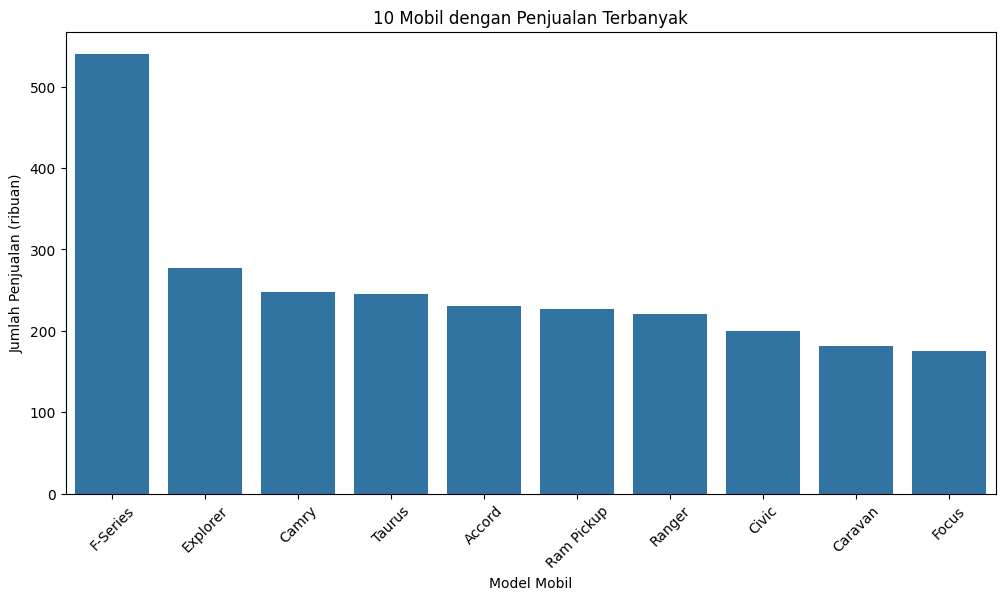

In [43]:
# Mengambil 10 mobil dengan penjualan tertinggi
best_sales = car.sort_values(by='Sales_in_thousands', ascending=False).head(10)

# Visualisasi
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Sales_in_thousands', data=best_sales)
plt.xticks(rotation=45)
plt.title('10 Mobil dengan Penjualan Terbanyak')
plt.xlabel('Model Mobil')
plt.ylabel('Jumlah Penjualan (ribuan)')
plt.show()

Penjelasan:
Grafik menunjukkan 10 jenis mobil dengan jumlah penjualan tertinggi. Mobil dengan penjualan tinggi menunjukkan bahwa kendaraan tersebut memiliki spesifikasi yang diminati pasar.

## b. Menampilkan harga dan penjelasan dari 10 jenis mobil dengan jumlah penjualan terbanyak

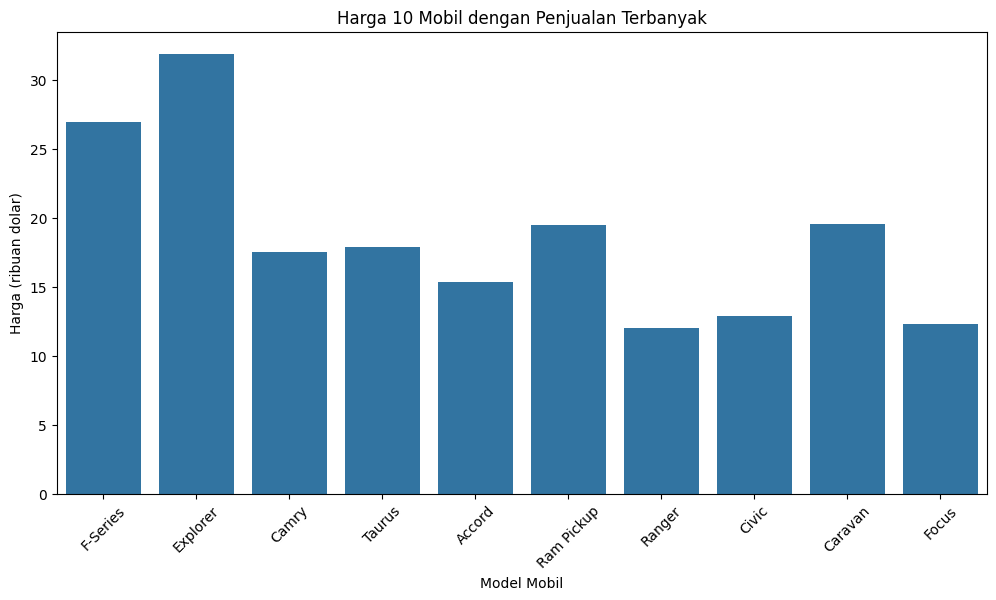

In [44]:
# Menampilkan model dan harga
best_sales[['Model', 'Price_in_thousands']]

# Visualisasi harga
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Price_in_thousands', data=best_sales)
plt.xticks(rotation=45)
plt.title('Harga 10 Mobil dengan Penjualan Terbanyak')
plt.xlabel('Model Mobil')
plt.ylabel('Harga (ribuan dolar)')
plt.show()

Penjelasan:
Harga mobil yang memiliki penjualan tinggi cenderung berada pada rentang harga menengah sehingga lebih mudah dijangkau konsumen.

## c. Menampilkan minimal 3 variabel/atribut lain dan penjelasan dari 10 jenis mobil dengan jumlah penjualan terbanyak

###1. Horsepower

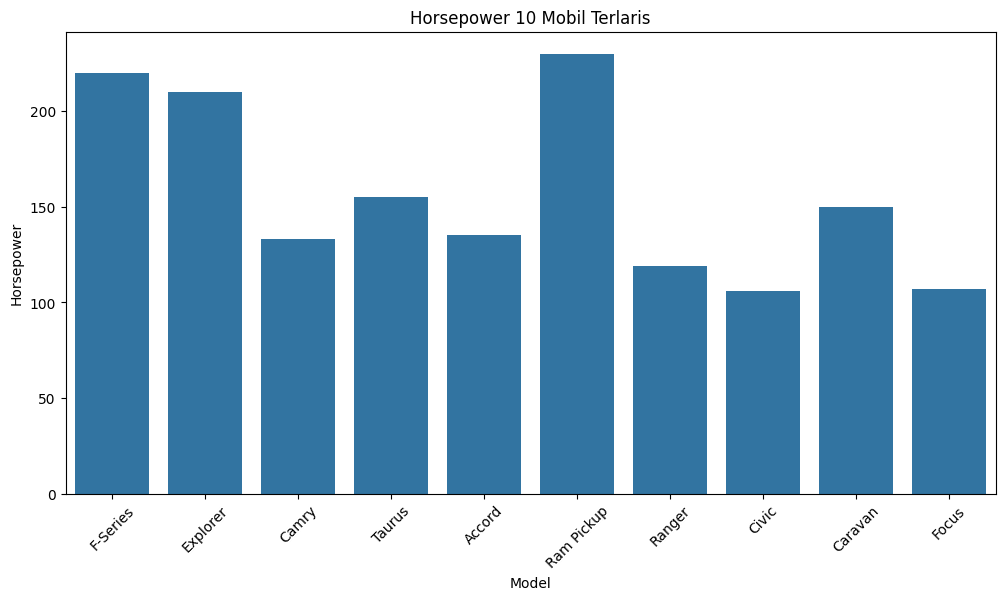

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Horsepower', data=best_sales)
plt.xticks(rotation=45)
plt.title('Horsepower 10 Mobil Terlaris')
plt.show()

Penjelasan:
Mobil terlaris umumnya memiliki horsepower yang cukup tinggi sehingga memberikan performa yang baik.

### 2. Fuel Efficiency

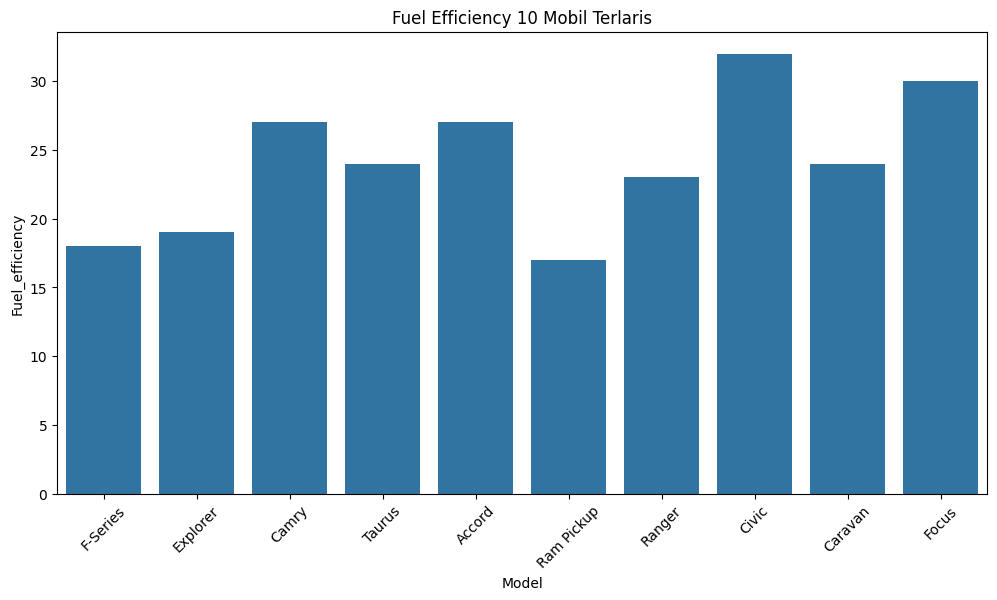

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Fuel_efficiency', data=best_sales)
plt.xticks(rotation=45)
plt.title('Fuel Efficiency 10 Mobil Terlaris')
plt.show()

Penjelasan:
Mobil dengan efisiensi bahan bakar yang baik cenderung lebih diminati karena lebih hemat dalam penggunaan sehari-hari.

### 3. Engine Size

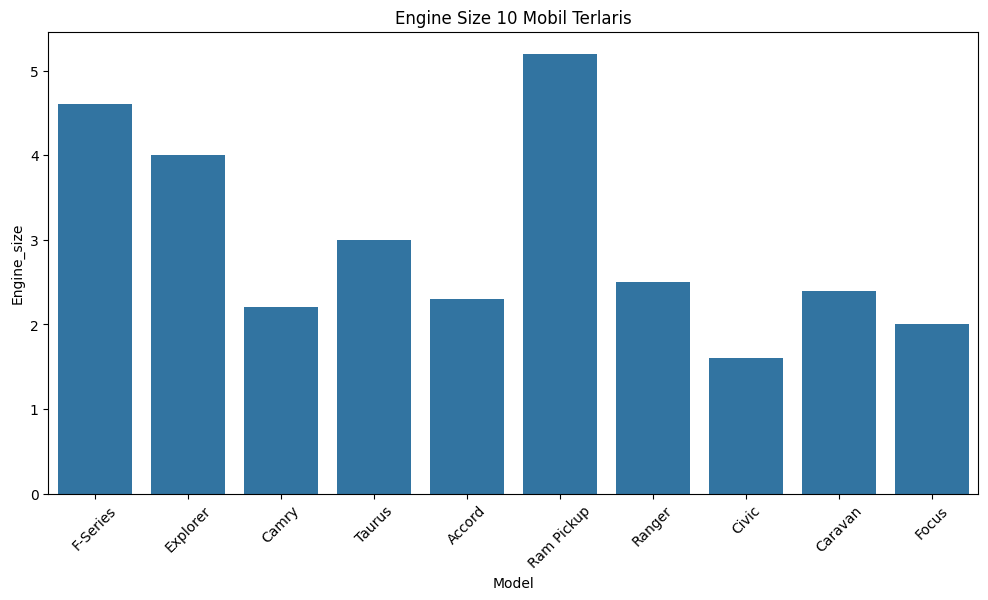

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Engine_size', data=best_sales)
plt.xticks(rotation=45)
plt.title('Engine Size 10 Mobil Terlaris')
plt.show()

Penjelasan:
Ukuran mesin mempengaruhi performa kendaraan. Mobil dengan engine size sedang hingga besar cukup diminati pasar.

## 7. Menentukan Variabel yang Digunakan sebagai Rekomendasi

Variabel yang digunakan dalam menentukan spesifikasi mobil dan prediksi harga adalah:

1. Engine_size
2. Horsepower
3. Wheelbase
4. Width
5. Length
6. Curb_weight
7. Fuel_capacity
8. Fuel_efficiency
9. Power_perf_factor

Penjelasan:
Variabel tersebut dipilih karena memiliki hubungan langsung terhadap performa, kenyamanan, efisiensi, dan harga kendaraan.

## 8. Membuat Model Prediksi Harga Mobil Menggunakan Linear Regression

## a. Memisahkan Variabel Independent dan Dependent

In [48]:
# Memilih fitur
features = [
    'Engine_size',
    'Horsepower',
    'Wheelbase',
    'Width',
    'Length',
    'Curb_weight',
    'Fuel_capacity',
    'Fuel_efficiency',
    'Power_perf_factor'
]

X = car[features]
y = car['Price_in_thousands']

Penjelasan:
Variabel independent (X) digunakan sebagai fitur prediksi, sedangkan Price_in_thousands menjadi variabel dependent (y).

## b. Memisahkan Data Training 80% dan Testing 20%

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Penjelasan:
Sebanyak 80% data digunakan untuk training dan 20% digunakan untuk testing model.

## c. Membuat Model Regresi

In [50]:
# Membuat model
model = LinearRegression()

# Training model
model.fit(X_train, y_train)

LinearRegression()

Penjelasan:
Model Linear Regression digunakan untuk memprediksi harga mobil berdasarkan spesifikasi kendaraan.

## d. Mengevaluasi Model dengan RMSE dan R2 Score

In [51]:
# Prediksi data testing
y_pred = model.predict(X_test)

# Evaluasi model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE :', rmse)
print('R2 Score :', r2)

RMSE : 3.459004148369765
R2 Score : 0.9692571419589978


Penjelasan:
RMSE digunakan untuk mengukur tingkat kesalahan prediksi model. Semakin kecil nilai RMSE maka model semakin baik.

R2 Score digunakan untuk melihat kemampuan model dalam menjelaskan variasi data. Semakin mendekati 1 maka model semakin baik.

## e. Menggambarkan Hasil Evaluasi dengan Scatter Plot

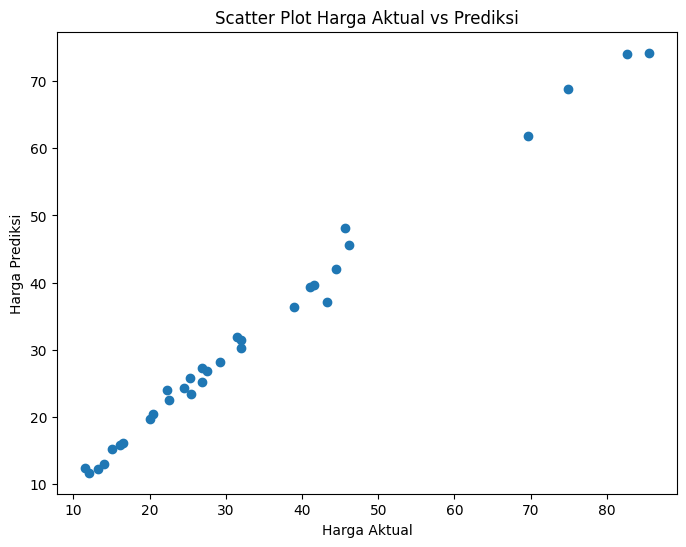

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi')
plt.title('Scatter Plot Harga Aktual vs Prediksi')
plt.show()

Penjelasan:
Scatter plot digunakan untuk membandingkan hasil prediksi model dengan data aktual. Semakin dekat titik terhadap garis diagonal maka prediksi model semakin akurat.

## 9. Memprediksi Harga dengan Spesifikasi Mobil yang Ditentukan

In [53]:
# Membuat dataframe input baru
input_data = pd.DataFrame({
    'Engine_size': [2.5],
    'Horsepower': [200],
    'Wheelbase': [110],
    'Width': [70],
    'Length': [190],
    'Curb_weight': [3.2],
    'Fuel_capacity': [17],
    'Fuel_efficiency': [28],
    'Power_perf_factor': [80]
})

# Prediksi harga
prediksi_harga = model.predict(input_data)

## 10. Menampilkan Hasil Prediksi Harga

In [54]:
print('Prediksi Harga Mobil :', prediksi_harga[0], 'ribuan dolar')

Prediksi Harga Mobil : 25.68042533061016 ribuan dolar


Penjelasan:
Model berhasil memberikan estimasi harga mobil berdasarkan spesifikasi yang diinputkan.

#11. Deployment Model Menggunakan Streamlit

Deployment dilakukan menggunakan Streamlit agar model dapat diakses melalui web browser.

###a. Install Streamlit

In [55]:
!pip install streamlit

Penjelasan: Library Streamlit diinstall agar aplikasi web prediksi harga mobil dapat dijalankan.

###b. Menyimpan Model

In [56]:
import pickle

# Menyimpan model
with open('model_mobil.pkl', 'wb') as file:
    pickle.dump(model, file)

print('Model berhasil disimpan')

Model berhasil disimpan


Penjelasan: Model Linear Regression disimpan ke dalam file .pkl agar dapat digunakan kembali pada aplikasi web Streamlit tanpa perlu melakukan training ulang.

###c. Download File Model

In [57]:
from google.colab import files

files.download('model_mobil.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Penjelasan: File model_mobil.pkl didownload agar dapat digunakan pada proses deployment aplikasi Streamlit.

##Kesimpulan

Berdasarkan hasil analisis data dan pembuatan model menggunakan metode Linear Regression, sistem berhasil memprediksi harga mobil berdasarkan spesifikasi kendaraan seperti engine size, horsepower, fuel efficiency, dan power performance factor. Model yang dibuat mampu memberikan estimasi harga mobil dengan cukup baik berdasarkan hasil evaluasi menggunakan RMSE dan R2 Score.

Selain itu, sistem juga berhasil dikembangkan menjadi aplikasi berbasis web menggunakan Streamlit sehingga pengguna dapat melakukan prediksi harga mobil secara langsung melalui browser dengan menginput spesifikasi kendaraan yang diinginkan.

## Langkah Selanjutnya Deployment

Setelah seluruh proses pada Google Colab selesai dilakukan, langkah berikutnya adalah membuat deployment aplikasi agar dapat dijalankan melalui web browser.

Langkah-langkah selanjutnya:
1. Menyimpan model Linear Regression ke dalam file model_mobil.pkl.
2. Membuat file app.py yang berisi kode aplikasi Streamlit.
3. Membuat file requirements.txt yang berisi daftar library yang digunakan.
4. Menjalankan aplikasi Streamlit secara lokal menggunakan perintah:

streamlit run app.py

5. Mengupload file deployment ke GitHub.
6. Melakukan deployment aplikasi menggunakan Streamlit Community Cloud agar aplikasi dapat diakses secara online.

Dengan deployment tersebut, sistem prediksi harga mobil dapat digunakan secara lebih mudah dan interaktif oleh pengguna melalui halaman web.